# 05 — Focal-Region Loss Masking for U-Net Territorial Control
## Addressing class imbalance by concentrating the training signal on contested cells


## Rationale

### The problem: gradient dilution from stable cells

The target variable is severely imbalanced: roughly 63% of labelled cell-months are
stable government control, 21% opposition, and 16% contested. More critically, only
about 2% of cell-months in the full panel exhibit a *control change* from the previous
month. The U-Net trained on the full labelled set therefore receives overwhelmingly
stable-cell gradient signal, which encourages it to reproduce the status quo rather
than learn to detect transitions — precisely the observations that matter for conflict
early warning.

### Why loss masking, not data filtering

An alternative approach would be to drop stable cell-months from training entirely
(hard resampling). Loss masking is preferable here for three reasons:

1. **Spatial context.** The U-Net encoder sees the full 40×16 raster on every forward
   pass. Filtering training examples would remove the contextual information that
   surrounds contested cells — exactly the spatial structure the encoder needs to
   learn stable vs. contested neighbourhood patterns.

2. **Representational stability.** With only ~23 training months, hard resampling
   creates batches with very few cells per month; the raster becomes nearly empty,
   which destabilises BatchNorm statistics and Dice loss computation.

3. **Interpretability.** Loss masking is a transparent, locally applied intervention:
   the model still *sees* all cells but is only *penalised* on cells in the focal
   region. This preserves the full-raster inference path and keeps the evaluation
   directly comparable to the baseline.

### The focal region

The focal mask is constructed as follows:

- A cell is marked *changing* if its control label differs across any two months in
  the 29-month panel (Nov 2023 – Mar 2026).
- Every *changing* cell plus all cells within a queen-contiguity radius
  (`NEIGHBOR_RADIUS`, default 1) are included in the focal mask.
- The mask is static (identical across all months) and saved to disk.

Using the full panel (not just training months) to define the mask reflects the idea
that we are encoding *geographic* contestedness — which regions of Myanmar are
structurally contested — not temporal dynamics. The mask adds no predictive signal
about future labels; it only tells the loss function where to concentrate its attention.

### Why validation stays unmasked

Masking validation would make the two runs incomparable (different effective test
populations) and would hide the baseline's advantage on stable cells. All validation
scores are computed on every labelled cell-month regardless of focal membership.

### Expected trade-off

The masked model is expected to trade a small drop in stable-cell accuracy for a
meaningful gain in transition recall. If transition recall does not improve, the
masking is not helping and should be abandoned or redesigned (e.g., softer weights
rather than hard masking, or a smaller/larger radius). Results are reported honestly
either way.


In [1]:
# ── CELL 0: Reproducibility ──────────────────────────────────────────────────
import random, os
import numpy as np
import torch

SEED = 20269999

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, 'mps'):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, 'manual_seed') else None
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f'Global seed fixed: {SEED}')


Global seed fixed: 20269999


In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
# Edit here; everything downstream adapts automatically.

TRAIN_CUTOFF    = '2025-01'   # same split as notebook 03 (baseline)

NEIGHBOR_RADIUS = 1           # queen-contiguity dilation radius for focal mask
                              # 1 = immediate 8-neighbors; try 2 for a wider focal zone

FOCAL_OUT_WEIGHT = 0.0        # CE loss weight for cells OUTSIDE the focal mask
                              # 0.0 = hard mask; 0.05 = soft mask (small stable signal)

NUM_EPOCHS    = 200
BATCH_SIZE    = 8
LEARNING_RATE = 1e-4
FREEZE_EPOCHS = 30
UNFREEZE_LR   = 1e-5

CHECKPOINT_BASELINE = 'unet_myanmar_best.pt'           # reuse existing 03 checkpoint
CHECKPOINT_MASKED   = 'unet_myanmar_focal_mask.pt'     # new artifact for masked model

print(f'Train cutoff   : {TRAIN_CUTOFF}')
print(f'Neighbor radius: {NEIGHBOR_RADIUS}')
print(f'Focal out wt   : {FOCAL_OUT_WEIGHT}')
print(f'Epochs         : {NUM_EPOCHS}')


Train cutoff   : 2025-01
Neighbor radius: 1
Focal out wt   : 0.0
Epochs         : 200


In [3]:
# ── CELL 1: Imports, Paths, Target Variable ───────────────────────────────────
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import segmentation_models_pytorch as smp
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from scipy.ndimage import binary_dilation
import copy, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
REPORTS      = PROJECT_ROOT / 'reports' / 'figures'
MODELS_DIR   = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

target = pd.read_parquet(DATA_PROC / '10_target_variable.parquet')
target['year_month'] = target['year_month'].astype(str)

print(f'Target rows: {len(target):,}  |  months: {target["year_month"].nunique()}'
      f'  |  cells: {target["priogrid_gid"].nunique()}')
print('\nClass distribution:')
print(target['target'].value_counts())


/Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Target rows: 5,238  |  months: 29  |  cells: 185

Class distribution:
target
gov          3303
opo          1110
uncertain     825
Name: count, dtype: int64


In [4]:
# ── CELL 2: Build Raster Dataset ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

features = pd.read_csv(DATA_PROC / 'myanmar_priogrid_features.csv')
features['year_month'] = features['year_month'].astype(str)

INPUT_FEATURES = [
    'total_events', 'total_fatalities', 'events_gov', 'events_nug',
    'events_ula', 'events_kio', 'gov_vs_civilians', 'gov_event_share',
    'total_events_lag1', 'total_fatalities_lag1',
]
NUM_CHANNELS = len(INPUT_FEATURES)

# PRIOGRID cell → (local_row, local_col) ─────────────────────────────────────
def gid_to_rowcol(gid):
    return (gid - 1) // 720, (gid - 1) % 720

all_gids = features['priogrid_gid'].unique()
gid_coords = {}
for gid in all_gids:
    r, c = gid_to_rowcol(gid)
    gid_coords[gid] = {'global_row': r, 'global_col': c}
coords_df = pd.DataFrame.from_dict(gid_coords, orient='index')
coords_df.index.name = 'priogrid_gid'

min_global_row = coords_df['global_row'].min()
min_global_col = coords_df['global_col'].min()
coords_df['local_row'] = coords_df['global_row'] - min_global_row
coords_df['local_col'] = coords_df['global_col'] - min_global_col

RASTER_H = coords_df['local_row'].max() + 1
RASTER_W = coords_df['local_col'].max() + 1
PAD_H    = int(np.ceil(RASTER_H / 8) * 8)
PAD_W    = int(np.ceil(RASTER_W / 8) * 8)

gid_to_local = coords_df[['local_row','local_col']].to_dict('index')

# Join features + labels ─────────────────────────────────────────────────────
LABEL_MAP = {'gov': 0, 'opo': 1, 'uncertain': 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}

labelled = features.merge(
    target[['priogrid_gid','year_month','target']],
    on=['priogrid_gid','year_month'], how='inner'
)
labelled['label_int'] = labelled['target'].map(LABEL_MAP)

# Normalise on training statistics ───────────────────────────────────────────
train_mask_rows = labelled['year_month'] <= TRAIN_CUTOFF
feat_means = labelled.loc[train_mask_rows, INPUT_FEATURES].mean()
feat_stds  = labelled.loc[train_mask_rows, INPUT_FEATURES].std().replace(0, 1)
labelled[INPUT_FEATURES] = (labelled[INPUT_FEATURES] - feat_means) / feat_stds

# Build monthly rasters ───────────────────────────────────────────────────────
months_with_labels = sorted(labelled['year_month'].unique())
X_rasters, y_rasters, masks_r, month_keys = [], [], [], []

for month in months_with_labels:
    md_  = labelled[labelled['year_month'] == month]
    X_r  = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)
    y_r  = np.full( (PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
    msk  = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
    for _, row in md_.iterrows():
        gid = row['priogrid_gid']
        if gid not in gid_to_local: continue
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        X_r[lr, lc, :] = row[INPUT_FEATURES].values
        y_r[lr, lc]    = row['label_int']
        msk[lr, lc]    = 1
    X_rasters.append(np.transpose(X_r, (2,0,1)))
    y_rasters.append(y_r); masks_r.append(msk); month_keys.append(month)

X_array = np.stack(X_rasters); y_array = np.stack(y_rasters); m_array = np.stack(masks_r)

# Train / val split ───────────────────────────────────────────────────────────
train_idx = [i for i, m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx   = [i for i, m in enumerate(month_keys) if m >  TRAIN_CUTOFF]

X_train, y_train, m_train = X_array[train_idx], y_array[train_idx], m_array[train_idx]
X_val,   y_val,   m_val   = X_array[val_idx],   y_array[val_idx],   m_array[val_idx]

val_month_keys = [month_keys[i] for i in val_idx]

print(f'Raster shape: {X_array.shape}  (months x channels x H x W)')
print(f'Train months: {len(train_idx)}  ({month_keys[train_idx[0]]} → {month_keys[train_idx[-1]]})')
print(f'Val   months: {len(val_idx)}   ({month_keys[val_idx[0]]} → {month_keys[val_idx[-1]]})')


Raster shape: (29, 10, 40, 16)  (months x channels x H x W)
Train months: 15  (2023-11 → 2025-01)
Val   months: 14   (2025-02 → 2026-03)


Total labelled cells      : 149
Cells that change label   : 85  (57.0%)
Cells always stable       : 64

── Focal Mask Statistics (radius=1) ──
  Focal mask pixels        : 271 / 640  (42.3% of raster)
  Avg labelled cells/month : 146
  Train cell-months in focal mask     : 1,873 / 2,143 (87.4%)
  Of those, cells that ever change    : 1,241 (66.3%)
  Gradient concentrated on: 1,873 cell-months (vs 2,143 in baseline)

Focal mask saved to: /Users/felipe/Documents/BSE/Thesis/territorial_control_dsdm_master_project/models/focal_mask_r1.npy


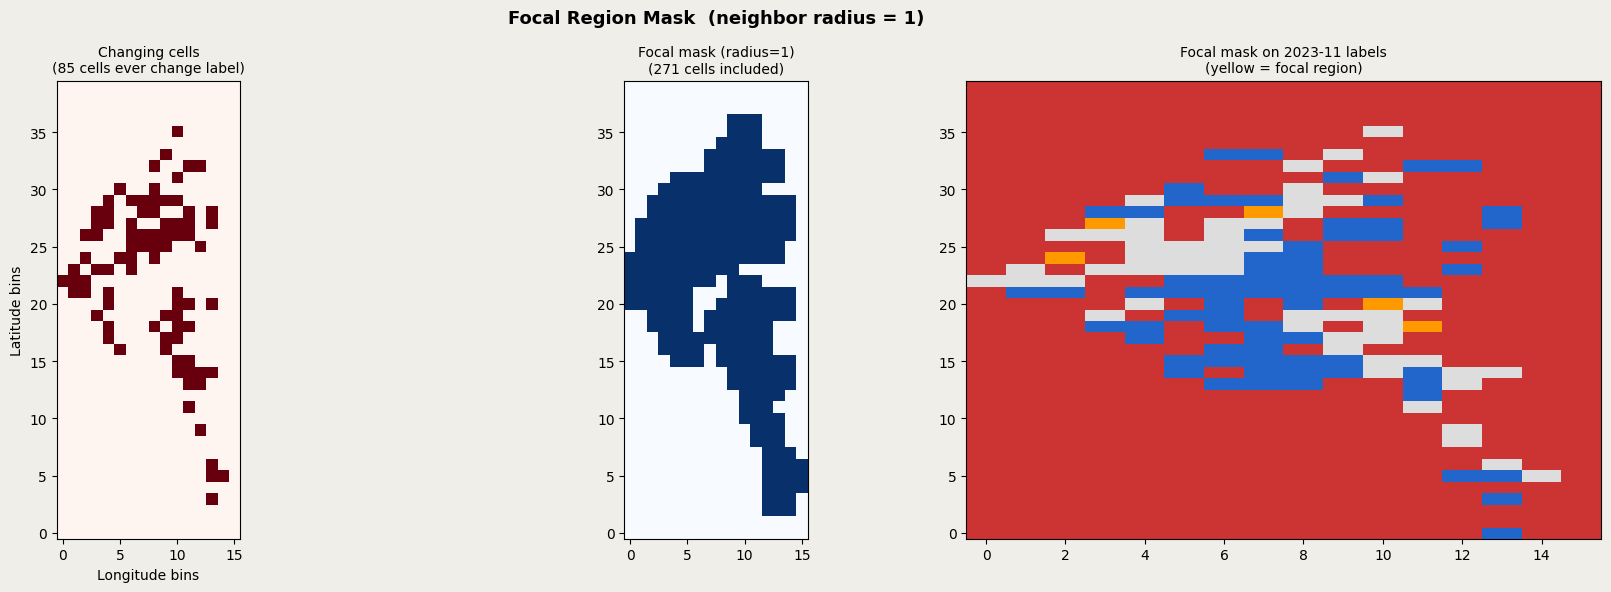

Focal mask figure saved.


In [5]:
# ── CELL 3: Build Focal Mask ─────────────────────────────────────────────────
# Identify which raster cells ever change control over the full 29-month panel,
# then dilate by NEIGHBOR_RADIUS to include spatial context.

# ── 3.1 Find changing cells ──────────────────────────────────────────────────
# A cell 'changes' if it has >= 2 distinct labels across all months.

label_by_gid = labelled.groupby('priogrid_gid')['label_int'].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index)

print(f'Total labelled cells      : {len(label_by_gid):,}')
print(f'Cells that change label   : {len(changing_gids):,}'
      f'  ({100*len(changing_gids)/len(label_by_gid):.1f}%)')
print(f'Cells always stable       : {len(label_by_gid) - len(changing_gids):,}')

# ── 3.2 Build binary raster of changing cells (PAD_H x PAD_W) ───────────────
changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster[lr, lc] = True

# ── 3.3 Dilate by NEIGHBOR_RADIUS (queen contiguity) ────────────────────────
# binary_dilation with a square structuring element includes all cells
# within NEIGHBOR_RADIUS steps in any direction (including diagonals).
struct = np.ones((2*NEIGHBOR_RADIUS+1, 2*NEIGHBOR_RADIUS+1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)  # (PAD_H, PAD_W) bool

# ── 3.4 Report coverage ──────────────────────────────────────────────────────
n_focal       = focal_mask_np.sum()
n_all_cells   = m_array.sum(axis=(1,2)).mean()  # avg labelled cells per month
n_total_px    = PAD_H * PAD_W

# Of all labelled cell-months in training, how many are in the focal region?
focal_mask_3d = focal_mask_np[np.newaxis, :, :]  # (1, H, W) broadcast
n_focal_labelled_train = int((m_train * focal_mask_3d).sum())
n_total_labelled_train = int(m_train.sum())

# Of those focal labelled train cell-months, what fraction actually changed?
# A 'change' cell-month is one where the cell is in changing_gids
changing_raster_labeled = np.zeros((PAD_H, PAD_W), dtype=np.uint8)
for gid in changing_gids:
    if gid in gid_to_local:
        lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
        changing_raster_labeled[lr, lc] = 1

n_actual_change_train = int((m_train * changing_raster_labeled[np.newaxis]).sum())

print(f'\n── Focal Mask Statistics (radius={NEIGHBOR_RADIUS}) ──')
print(f'  Focal mask pixels        : {n_focal} / {n_total_px}'
      f'  ({100*n_focal/n_total_px:.1f}% of raster)')
print(f'  Avg labelled cells/month : {n_all_cells:.0f}')
print(f'  Train cell-months in focal mask     : {n_focal_labelled_train:,}'
      f' / {n_total_labelled_train:,}'
      f' ({100*n_focal_labelled_train/n_total_labelled_train:.1f}%)')
print(f'  Of those, cells that ever change    : {n_actual_change_train:,}'
      f' ({100*n_actual_change_train/max(n_focal_labelled_train,1):.1f}%)')
print(f'  Gradient concentrated on: {n_focal_labelled_train:,} cell-months'
      f' (vs {n_total_labelled_train:,} in baseline)')

# ── 3.5 Save mask to disk ────────────────────────────────────────────────────
mask_path = MODELS_DIR / f'focal_mask_r{NEIGHBOR_RADIUS}.npy'
np.save(mask_path, focal_mask_np)
print(f'\nFocal mask saved to: {mask_path}')

# ── 3.6 Visualise focal mask ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='#F0EEE8')
fig.suptitle(f'Focal Region Mask  (neighbor radius = {NEIGHBOR_RADIUS})',
             fontsize=13, fontweight='bold')

# Panel 1: changing cells only
ax = axes[0]
ax.imshow(changing_raster.astype(float), cmap='Reds', origin='lower', vmin=0, vmax=1)
ax.set_title(f'Changing cells\n({len(changing_gids)} cells ever change label)', fontsize=10)
ax.set_xlabel('Longitude bins'); ax.set_ylabel('Latitude bins')

# Panel 2: focal mask (changing + neighbors)
ax = axes[1]
ax.imshow(focal_mask_np.astype(float), cmap='Blues', origin='lower', vmin=0, vmax=1)
ax.set_title(f'Focal mask (radius={NEIGHBOR_RADIUS})\n({n_focal} cells included)', fontsize=10)

# Panel 3: focal mask overlaid on a sample label raster
ax = axes[2]
label_cmap  = mcolors.ListedColormap(['#CC3333','#2266CC','#FF9900','#DDDDDD'])
label_bounds = [-1.5,-0.5,0.5,1.5,2.5]
label_norm   = mcolors.BoundaryNorm(label_bounds, label_cmap.N)
ax.imshow(y_train[0], cmap=label_cmap, norm=label_norm, origin='lower', aspect='auto')
# Overlay focal mask boundary
from matplotlib.colors import ListedColormap
overlay = np.ma.masked_where(~focal_mask_np, np.ones_like(focal_mask_np, dtype=float))
ax.imshow(overlay, cmap=ListedColormap(['none','yellow']), origin='lower',
          alpha=0.35, aspect='auto')
ax.set_title(f'Focal mask on {month_keys[train_idx[0]]} labels\n(yellow = focal region)', fontsize=10)

plt.tight_layout()
fig.savefig(REPORTS / f'focal_mask_r{NEIGHBOR_RADIUS}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Focal mask figure saved.')


In [6]:
# ── CELL 4: Model Architecture and Loss Functions ────────────────────────────

# ── 4.1 Device ───────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

# ── 4.2 Hyperparameters ───────────────────────────────────────────────────────
NUM_CLASSES  = 3
ENCODER_NAME    = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'

# ── 4.3 Class weights (inverse frequency) ────────────────────────────────────
label_counts     = np.array([
    (labelled['label_int'] == 0).sum(),
    (labelled['label_int'] == 1).sum(),
    (labelled['label_int'] == 2).sum(),
])
class_weights_np     = len(labelled) / (NUM_CLASSES * label_counts)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print(f'Class weights: gov={class_weights_np[0]:.3f}  opo={class_weights_np[1]:.3f}'
      f'  uncertain={class_weights_np[2]:.3f}')

# ── 4.4 Dice loss (shared by both loss functions) ────────────────────────────
dice_loss_fn = smp.losses.DiceLoss(mode='multiclass', from_logits=True, smooth=1.0)

# ── 4.5 Baseline combined loss (same as notebook 03) ─────────────────────────
def combined_loss(predictions, targets, mask):
    """CE + Dice on all labelled cells (no focal masking)."""
    safe_targets = targets.clone()
    safe_targets[mask == 0] = 0

    preds_hwc   = predictions.permute(0,2,3,1)      # (B,H,W,C)
    valid_preds = preds_hwc[mask == 1]               # (N, C)
    valid_tgts  = targets[mask == 1]                 # (N,)

    if valid_preds.shape[0] == 0:
        return torch.tensor(0.0, requires_grad=True, device=predictions.device)

    ce = F.cross_entropy(valid_preds, valid_tgts, weight=class_weights_tensor)
    dc = dice_loss_fn(predictions, safe_targets)
    return 0.5 * ce + 0.5 * dc


# ── 4.6 Focal combined loss ───────────────────────────────────────────────────
# Key design:
#   CE   — per-pixel, weighted by (label_mask AND focal_mask).
#          Cells outside the focal region contribute weight FOCAL_OUT_WEIGHT to CE.
#   Dice — applied to the full labelled region (preserves spatial shape signal).
# The full-raster prediction still flows through the encoder; only the CE gradient
# is concentrated. This is different from zeroing out predictions before the loss.

# Pre-compute the focal mask tensor once (static across all epochs)
focal_mask_tensor = torch.from_numpy(focal_mask_np).bool().to(DEVICE)  # (H, W)

def focal_combined_loss(predictions, targets, label_mask):
    """
    CE + Dice where CE is weighted by focal_mask.
    predictions : (B, C, H, W)  logits
    targets     : (B, H, W)     int64 labels (-1 = no label)
    label_mask  : (B, H, W)     uint8, 1=labelled
    """
    B = predictions.shape[0]

    # pixel weight: (B, H, W) — in-focal + labelled gets 1.0, out-of-focal + labelled
    # gets FOCAL_OUT_WEIGHT, unlabelled always 0.
    focal_broad = focal_mask_tensor.unsqueeze(0).expand(B, -1, -1)  # (B, H, W)
    pixel_w = torch.where(
        focal_broad,
        label_mask.float(),                         # focal cells: full weight if labelled
        label_mask.float() * FOCAL_OUT_WEIGHT,      # non-focal: reduced weight if labelled
    )  # (B, H, W)

    # CE per-pixel (reduction='none') using class weights via manual computation
    safe_targets = targets.clone()
    safe_targets[label_mask == 0] = 0  # dummy class for unlabelled (masked out by pixel_w)

    ce_per_pixel = F.cross_entropy(
        predictions, safe_targets,
        weight=class_weights_tensor,
        reduction='none',
    )  # (B, H, W)

    n_effective = pixel_w.sum() + 1e-8
    ce = (ce_per_pixel * pixel_w).sum() / n_effective

    # Dice: full labelled region (spatial shape signal; no focal restriction)
    dc = dice_loss_fn(predictions, safe_targets)

    return 0.5 * ce + 0.5 * dc


# ── 4.7 Model factory ─────────────────────────────────────────────────────────
def build_model():
    """Fresh U-Net with same seed — call before each training run."""
    random.seed(SEED); np.random.seed(SEED)
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
    m = smp.Unet(
        encoder_name=ENCODER_NAME, encoder_weights=ENCODER_WEIGHTS,
        in_channels=NUM_CHANNELS,  classes=NUM_CLASSES,
        activation=None, decoder_channels=(128,64,32,16), encoder_depth=4,
    ).to(DEVICE)
    return m

def build_optimizer(model):
    params = list(model.decoder.parameters()) + list(model.segmentation_head.parameters())
    opt = optim.Adam(params, lr=LEARNING_RATE, weight_decay=1e-5)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=10, factor=0.5)
    return opt, sch

print('Loss functions and model factory defined.')


Device: mps
Class weights: gov=0.552  opo=1.649  uncertain=1.719
Loss functions and model factory defined.


In [7]:
# ── CELL 5: Dataset, DataLoader Helpers, and Training Loop ───────────────────

class MyanmarRasterDataset(Dataset):
    def __init__(self, X, y, mask, augment=False):
        self.X       = X.astype(np.float32)
        self.y       = y.astype(np.int64)
        self.mask    = mask.astype(np.uint8)
        self.augment = augment
        self.T       = len(X)

    def __len__(self): return self.T

    def __getitem__(self, idx):
        X, y, mask = (torch.from_numpy(self.X[idx]),
                      torch.from_numpy(self.y[idx]),
                      torch.from_numpy(self.mask[idx]))
        if self.augment:
            if torch.rand(1).item() > 0.5:
                X, y, mask = (torch.flip(X,[2]), torch.flip(y,[1]), torch.flip(mask,[1]))
            if torch.rand(1).item() > 0.7:
                X, y, mask = (torch.flip(X,[1]), torch.flip(y,[0]), torch.flip(mask,[0]))
            X = X + torch.randn_like(X) * 0.05
        return X, y, mask


def seed_worker(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)


def make_loaders():
    g = torch.Generator(); g.manual_seed(SEED)
    train_ds = MyanmarRasterDataset(X_train, y_train, m_train, augment=True)
    val_ds   = MyanmarRasterDataset(X_val,   y_val,   m_val,   augment=False)
    tr_ld = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, drop_last=False,
                       generator=g, worker_init_fn=seed_worker)
    va_ld = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    return tr_ld, va_ld


def compute_metrics(logits, targets, mask, num_classes=3):
    preds = torch.argmax(logits, dim=1)
    vp, vt = preds[mask==1], targets[mask==1]
    if len(vt) == 0: return {'overall_acc': 0.0}
    acc = (vp == vt).float().mean().item()
    cls_acc = {}
    for c, name in enumerate(['gov','opo','uncertain']):
        cm = vt == c
        cls_acc[name] = (vp[cm] == c).float().mean().item() if cm.sum() > 0 else float('nan')
    return {'overall_acc': acc, **cls_acc}


def freeze_encoder(model):
    for p in model.encoder.parameters(): p.requires_grad = False
    print(f'  Encoder frozen ({sum(p.numel() for p in model.encoder.parameters()):,} params)')

def unfreeze_encoder(model, optimizer, new_lr):
    for p in model.encoder.parameters(): p.requires_grad = True
    optimizer.add_param_group({'params': list(model.encoder.parameters()), 'lr': new_lr})
    print(f'  Encoder unfrozen (lr={new_lr})')


def train_model(label, checkpoint_name, use_focal=False):
    """
    Full two-phase training.
    label           : string for print headers
    checkpoint_name : filename inside MODELS_DIR
    use_focal       : if True use focal_combined_loss for training, else combined_loss
    Validation ALWAYS uses combined_loss (unmasked) so metrics are comparable.
    Returns (history, model).
    """
    print(f'\n{"="*60}')
    print(f'TRAINING: {label}')
    print(f'  Loss: {"focal_combined_loss" if use_focal else "combined_loss (baseline)"}')
    print(f'  Checkpoint: {checkpoint_name}')
    print(f'{"="*60}')

    ckpt_path   = MODELS_DIR / checkpoint_name
    model       = build_model()
    opt, sched  = build_optimizer(model)
    tr_ld, va_ld = make_loaders()

    history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc',
                                'val_acc_gov','val_acc_opo','val_acc_uncertain','lr']}
    best_val_loss, best_wts = float('inf'), None

    freeze_encoder(model)

    for epoch in range(1, NUM_EPOCHS + 1):
        if epoch == FREEZE_EPOCHS + 1:
            print(f'  ── Phase 2: unfreezing encoder (epoch {epoch})')
            unfreeze_encoder(model, opt, UNFREEZE_LR)

        # ── Training pass ─────────────────────────────────────────────────────
        model.train()
        e_loss, e_acc, nb = 0.0, 0.0, 0
        for Xb, yb, mb in tr_ld:
            Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
            opt.zero_grad()
            preds = model(Xb)
            loss  = focal_combined_loss(preds, yb, mb) if use_focal else combined_loss(preds, yb, mb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            with torch.no_grad():
                m_ = compute_metrics(preds, yb, mb)
            e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
        avg_tl, avg_ta = e_loss / nb, e_acc / nb

        # ── Validation pass (always unmasked combined_loss) ────────────────────
        model.eval()
        e_loss, e_acc, nb = 0.0, 0.0, 0
        cls_ = {'gov':[],'opo':[],'uncertain':[]}
        with torch.no_grad():
            for Xb, yb, mb in va_ld:
                Xb, yb, mb = Xb.to(DEVICE), yb.to(DEVICE), mb.to(DEVICE)
                preds = model(Xb)
                loss  = combined_loss(preds, yb, mb)
                m_    = compute_metrics(preds, yb, mb)
                e_loss += loss.item(); e_acc += m_['overall_acc']; nb += 1
                for c in ['gov','opo','uncertain']:
                    if not np.isnan(m_.get(c, float('nan'))): cls_[c].append(m_[c])
        avg_vl, avg_va = e_loss / nb, e_acc / nb
        avg_cls = {c: np.mean(v) if v else float('nan') for c, v in cls_.items()}

        sched.step(avg_vl)
        history['train_loss'].append(avg_tl); history['val_loss'].append(avg_vl)
        history['train_acc'].append(avg_ta);  history['val_acc'].append(avg_va)
        history['val_acc_gov'].append(avg_cls['gov'])
        history['val_acc_opo'].append(avg_cls['opo'])
        history['val_acc_uncertain'].append(avg_cls['uncertain'])
        history['lr'].append(opt.param_groups[0]['lr'])

        if avg_vl < best_val_loss:
            best_val_loss = avg_vl
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(best_wts, ckpt_path)
            ck = ' <- best'
        else:
            ck = ''

        if epoch % 10 == 0 or epoch == 1:
            ph = 'P1' if epoch <= FREEZE_EPOCHS else 'P2'
            print(f'  Ep {epoch:>3}/{NUM_EPOCHS} [{ph}]  '
                  f'tr {avg_tl:.3f}/{avg_ta:.3f}  '
                  f'val {avg_vl:.3f}/{avg_va:.3f}  '
                  f'[g:{avg_cls["gov"]:.2f} o:{avg_cls["opo"]:.2f} u:{avg_cls["uncertain"]:.2f}]'
                  f'{ck}')

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    print(f'\nBest val loss: {best_val_loss:.4f}  |  checkpoint: {ckpt_path.name}')
    return history, model


print('Training function defined. Ready to train.')


Training function defined. Ready to train.


In [8]:
# ── CELL 6: Train Baseline Model (no focal mask) ─────────────────────────────
# This replicates the notebook-03 setup exactly.
# If you already have a trained checkpoint at MODELS_DIR/CHECKPOINT_BASELINE,
# you can skip re-training by loading it directly (see commented block below).

history_base, model_base = train_model(
    label           = 'BASELINE (no focal mask)',
    checkpoint_name = CHECKPOINT_BASELINE,
    use_focal       = False,
)

# ── Alternative: load existing checkpoint without re-training ─────────────────
# model_base = build_model()
# model_base.load_state_dict(torch.load(MODELS_DIR / CHECKPOINT_BASELINE, map_location=DEVICE))
# model_base.eval()
# print('Baseline checkpoint loaded (training skipped).')



TRAINING: BASELINE (no focal mask)
  Loss: combined_loss (baseline)
  Checkpoint: unet_myanmar_best.pt
  Encoder frozen (21,306,624 params)
  Ep   1/200 [P1]  tr 1.100/0.272  val 0.974/0.214  [g:0.03 o:0.32 u:0.88] <- best
  Ep  10/200 [P1]  tr 0.913/0.408  val 0.923/0.423  [g:0.36 o:0.41 u:0.77]
  Ep  20/200 [P1]  tr 0.825/0.538  val 0.892/0.511  [g:0.45 o:0.51 u:0.80] <- best
  Ep  30/200 [P1]  tr 0.795/0.590  val 0.829/0.576  [g:0.54 o:0.57 u:0.77] <- best
  ── Phase 2: unfreezing encoder (epoch 31)
  Encoder unfrozen (lr=1e-05)
  Ep  40/200 [P2]  tr 0.749/0.642  val 0.810/0.593  [g:0.56 o:0.59 u:0.77]
  Ep  50/200 [P2]  tr 0.702/0.692  val 0.798/0.613  [g:0.59 o:0.58 u:0.78]
  Ep  60/200 [P2]  tr 0.662/0.718  val 0.773/0.650  [g:0.64 o:0.61 u:0.79]
  Ep  70/200 [P2]  tr 0.634/0.743  val 0.752/0.653  [g:0.63 o:0.64 u:0.78]
  Ep  80/200 [P2]  tr 0.598/0.771  val 0.734/0.669  [g:0.64 o:0.67 u:0.80] <- best
  Ep  90/200 [P2]  tr 0.588/0.777  val 0.715/0.693  [g:0.67 o:0.68 u:0.83] <- 

In [9]:
# ── CELL 7: Train Masked Model (focal-region CE loss) ────────────────────────
# Same architecture, same hyperparameters, same seed.
# Only difference: CE loss is weighted by focal_mask during training.
# Validation uses unmasked combined_loss so scores are directly comparable.

history_masked, model_masked = train_model(
    label           = f'MASKED (focal mask, radius={NEIGHBOR_RADIUS})',
    checkpoint_name = CHECKPOINT_MASKED,
    use_focal       = True,
)



TRAINING: MASKED (focal mask, radius=1)
  Loss: focal_combined_loss
  Checkpoint: unet_myanmar_focal_mask.pt
  Encoder frozen (21,306,624 params)
  Ep   1/200 [P1]  tr 1.129/0.273  val 0.974/0.215  [g:0.03 o:0.33 u:0.88] <- best
  Ep  10/200 [P1]  tr 0.925/0.388  val 0.921/0.425  [g:0.37 o:0.40 u:0.75]
  Ep  20/200 [P1]  tr 0.843/0.502  val 0.923/0.441  [g:0.34 o:0.50 u:0.82]
  Ep  30/200 [P1]  tr 0.822/0.541  val 0.855/0.518  [g:0.44 o:0.56 u:0.81] <- best
  ── Phase 2: unfreezing encoder (epoch 31)
  Encoder unfrozen (lr=1e-05)
  Ep  40/200 [P2]  tr 0.802/0.554  val 0.855/0.532  [g:0.47 o:0.56 u:0.77] <- best
  Ep  50/200 [P2]  tr 0.756/0.614  val 0.844/0.550  [g:0.50 o:0.55 u:0.80] <- best
  Ep  60/200 [P2]  tr 0.737/0.645  val 0.825/0.571  [g:0.52 o:0.59 u:0.77] <- best
  Ep  70/200 [P2]  tr 0.711/0.627  val 0.803/0.580  [g:0.52 o:0.61 u:0.80] <- best
  Ep  80/200 [P2]  tr 0.689/0.677  val 0.790/0.613  [g:0.57 o:0.64 u:0.78] <- best
  Ep  90/200 [P2]  tr 0.677/0.666  val 0.779/0.6

  Baseline predictions  : 2,086 cell-months
  Masked predictions    : 2,086 cell-months

Classification Report — BASELINE
              precision    recall  f1-score   support

         gov      0.895     0.827     0.860      1310
         opo      0.825     0.699     0.757       501
   uncertain      0.551     0.905     0.685       275

    accuracy                          0.806      2086
   macro avg      0.757     0.810     0.767      2086
weighted avg      0.833     0.806     0.812      2086

Macro F1: 0.767   Accuracy: 0.806

Classification Report — MASKED
              precision    recall  f1-score   support

         gov      0.889     0.773     0.827      1310
         opo      0.741     0.681     0.710       501
   uncertain      0.474     0.840     0.606       275

    accuracy                          0.760      2086
   macro avg      0.702     0.765     0.714      2086
weighted avg      0.799     0.760     0.770      2086

Macro F1: 0.714   Accuracy: 0.760

HEAD-TO-HEAD CO

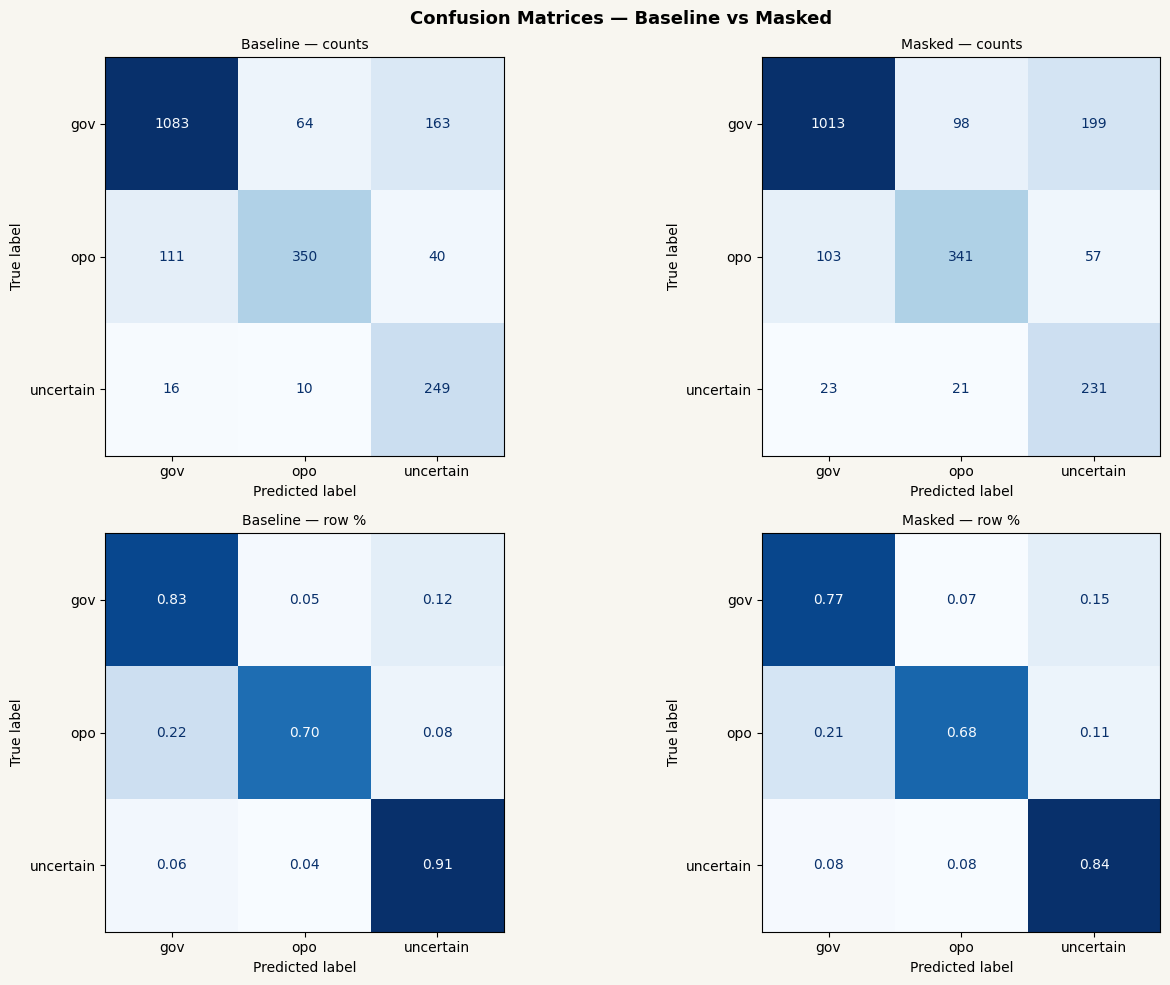

Confusion matrices saved.


In [10]:
# ── CELL 8: Evaluation — Side-by-Side Comparison ─────────────────────────────
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

CLASS_NAMES = ['gov', 'opo', 'uncertain']

# ── 8.1 Collect predictions per (gid, year_month) ────────────────────────────
# Working at (gid, year_month) level lets us compute transition-aware metrics.

def collect_predictions(model):
    """
    Run model on all validation months. Returns a dict:
        (priogrid_gid, year_month) -> predicted_class_int
    """
    pred_lookup = {}
    model.eval()
    with torch.no_grad():
        for i, month in enumerate(val_month_keys):
            X_t    = torch.from_numpy(X_val[i]).unsqueeze(0).to(DEVICE)  # (1,C,H,W)
            logits = model(X_t)                                            # (1,C,H,W)
            preds  = torch.argmax(logits, dim=1)[0].cpu().numpy()         # (H,W)
            for _, row in labelled[labelled['year_month'] == month].iterrows():
                gid = row['priogrid_gid']
                if gid not in gid_to_local: continue
                lr, lc = gid_to_local[gid]['local_row'], gid_to_local[gid]['local_col']
                pred_lookup[(gid, month)] = int(preds[lr, lc])
    return pred_lookup

print('Collecting predictions...')
preds_base   = collect_predictions(model_base)
preds_masked = collect_predictions(model_masked)
print(f'  Baseline predictions  : {len(preds_base):,} cell-months')
print(f'  Masked predictions    : {len(preds_masked):,} cell-months')

# ── 8.2 Build flat arrays for sklearn metrics ─────────────────────────────────
val_rows  = labelled[labelled['year_month'] > TRAIN_CUTOFF].copy()

y_true       = []
y_pred_base  = []
y_pred_mask  = []

for _, row in val_rows.iterrows():
    key = (row['priogrid_gid'], row['year_month'])
    if key not in preds_base: continue
    y_true.append(int(row['label_int']))
    y_pred_base.append(preds_base[key])
    y_pred_mask.append(preds_masked[key])

y_true      = np.array(y_true)
y_pred_base = np.array(y_pred_base)
y_pred_mask = np.array(y_pred_mask)

# ── 8.3 Standard classification reports ──────────────────────────────────────
for name, y_pred in [('BASELINE', y_pred_base), ('MASKED', y_pred_mask)]:
    print(f'\n{"="*60}')
    print(f'Classification Report — {name}')
    print(f'{"="*60}')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))
    mf1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'Macro F1: {mf1:.3f}   Accuracy: {(y_true==y_pred).mean():.3f}')

# ── 8.4 Transition recall and stable accuracy ─────────────────────────────────
# Build (gid, year_month) -> label_int lookup for prev-month lookup.

def prev_ym(ym):
    """Return the year-month string one month before ym."""
    y, m = int(ym[:4]), int(ym[5:7])
    m -= 1
    if m == 0: y -= 1; m = 12
    return f'{y:04d}-{m:02d}'

label_lookup = {
    (int(row['priogrid_gid']), row['year_month']): int(row['label_int'])
    for _, row in labelled.iterrows()
}

# For each validation cell-month, determine transition vs stable
trans_true_b, trans_pred_b = [], []
trans_true_m, trans_pred_m = [], []
stab_true_b,  stab_pred_b  = [], []
stab_true_m,  stab_pred_m  = [], []

for _, row in val_rows.iterrows():
    gid, ym = int(row['priogrid_gid']), row['year_month']
    key     = (gid, ym)
    if key not in preds_base: continue
    prev_key = (gid, prev_ym(ym))
    if prev_key not in label_lookup: continue   # no prior month in panel — skip

    cur_label  = int(row['label_int'])
    prev_label = label_lookup[prev_key]
    pb, pm     = preds_base[key], preds_masked[key]

    if cur_label != prev_label:    # transition cell-month
        trans_true_b.append(cur_label); trans_pred_b.append(pb)
        trans_true_m.append(cur_label); trans_pred_m.append(pm)
    else:                          # stable cell-month
        stab_true_b.append(cur_label);  stab_pred_b.append(pb)
        stab_true_m.append(cur_label);  stab_pred_m.append(pm)

trans_true_b = np.array(trans_true_b); trans_pred_b = np.array(trans_pred_b)
trans_true_m = np.array(trans_true_m); trans_pred_m = np.array(trans_pred_m)
stab_true_b  = np.array(stab_true_b);  stab_pred_b  = np.array(stab_pred_b)
stab_true_m  = np.array(stab_true_m);  stab_pred_m  = np.array(stab_pred_m)

tr_recall_b  = (trans_true_b == trans_pred_b).mean() if len(trans_true_b) else float('nan')
tr_recall_m  = (trans_true_m == trans_pred_m).mean() if len(trans_true_m) else float('nan')
st_acc_b     = (stab_true_b  == stab_pred_b ).mean() if len(stab_true_b)  else float('nan')
st_acc_m     = (stab_true_m  == stab_pred_m ).mean() if len(stab_true_m)  else float('nan')

# ── 8.5 Head-to-head summary table ───────────────────────────────────────────
macro_f1_b = f1_score(y_true, y_pred_base, average='macro', zero_division=0)
macro_f1_m = f1_score(y_true, y_pred_mask, average='macro', zero_division=0)
acc_b      = (y_true == y_pred_base).mean()
acc_m      = (y_true == y_pred_mask).mean()

print(f'\n{"="*70}')
print(f'HEAD-TO-HEAD COMPARISON — Full Validation Set (no masking)')
print(f'{"="*70}')
print(f'{"Metric":<35} {"Baseline":>12} {"Masked":>12} {"Delta":>10}')
print(f'{"-"*70}')
rows_cmp = [
    ('Accuracy',              acc_b,       acc_m),
    ('Macro F1',              macro_f1_b,  macro_f1_m),
    ('Transition recall',     tr_recall_b, tr_recall_m),
    ('Stable accuracy',       st_acc_b,    st_acc_m),
    (f'N transition cell-months', len(trans_true_b), len(trans_true_m)),
    (f'N stable cell-months',     len(stab_true_b),  len(stab_true_m)),
]
for rname, vb, vm in rows_cmp:
    if isinstance(vb, float):
        delta = vm - vb
        sign  = '+' if delta >= 0 else ''
        print(f'{rname:<35} {vb:>12.3f} {vm:>12.3f} {sign+f"{delta:.3f}":>10}')
    else:
        print(f'{rname:<35} {vb:>12} {vm:>12}')

print(f'\nKey diagnostic:')
if len(trans_true_b) == 0:
    print('  No transition cell-months in validation set — cannot compute transition recall.')
elif tr_recall_m > tr_recall_b:
    delta_tr = tr_recall_m - tr_recall_b
    delta_st = st_acc_m - st_acc_b
    print(f'  Masked model IMPROVES transition recall by {delta_tr:+.3f}')
    print(f'  Stable accuracy changes by {delta_st:+.3f} (expected small drop)')
    if abs(delta_st) < 0.02 * abs(delta_tr) + 0.01:
        print('  Trade-off is favourable: large transition recall gain, negligible stable loss.')
    else:
        print('  Trade-off: evaluate whether transition gain justifies stable accuracy cost.')
else:
    print(f'  Masked model does NOT improve transition recall '
        f'({tr_recall_b:.3f} base vs {tr_recall_m:.3f} masked).')
    print('  Masking is not helping. Consider: different radius, softer weights, or resampling.')

# ── 8.6 Confusion matrices ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='#F8F6F0')
fig.suptitle('Confusion Matrices — Baseline vs Masked', fontsize=13, fontweight='bold')

for col, (name, y_pred) in enumerate([('Baseline', y_pred_base), ('Masked', y_pred_mask)]):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    for row, (mat, fmt, title) in enumerate([
        (cm,      'd',   f'{name} — counts'),
        (cm_norm, '.2f', f'{name} — row %'),
    ]):
        ax = axes[row, col]
        ConfusionMatrixDisplay(mat, display_labels=CLASS_NAMES).plot(
            ax=ax, cmap='Blues', colorbar=False, values_format=fmt)
        ax.set_title(title, fontsize=10)

plt.tight_layout()
fig.savefig(REPORTS / 'focal_mask_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved.')


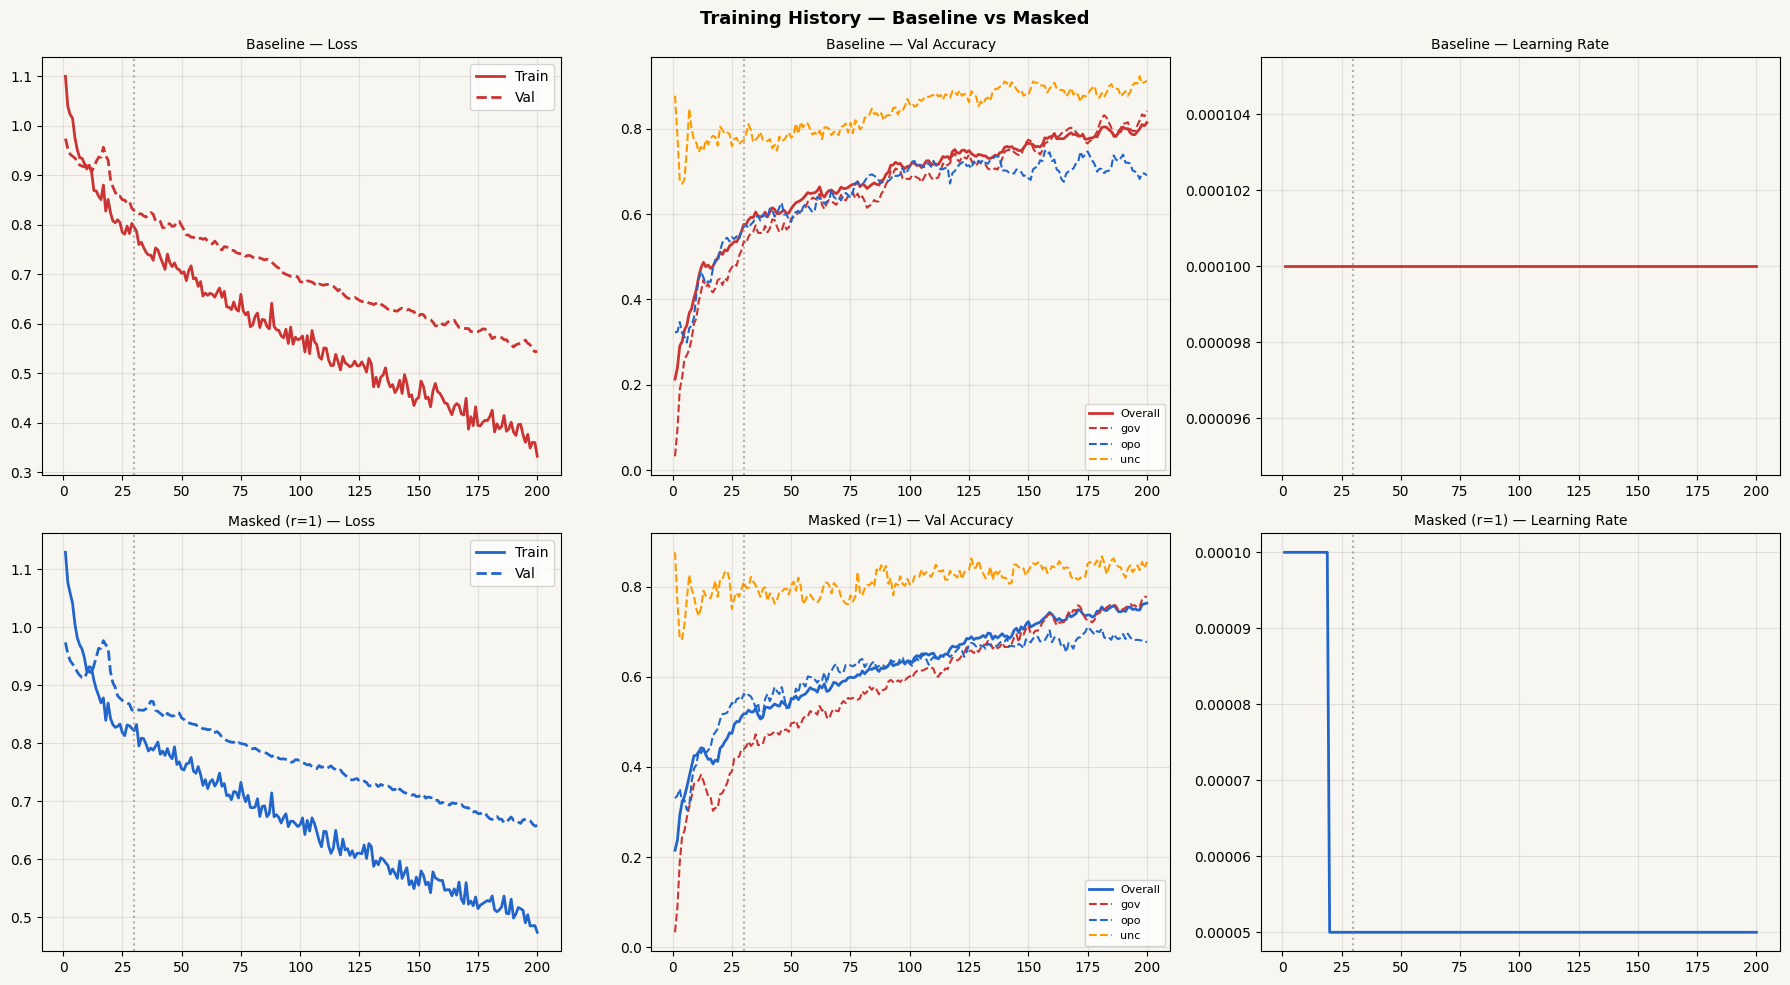

Training curves saved.
Showcase month: 2025-10  (9 changing cells)


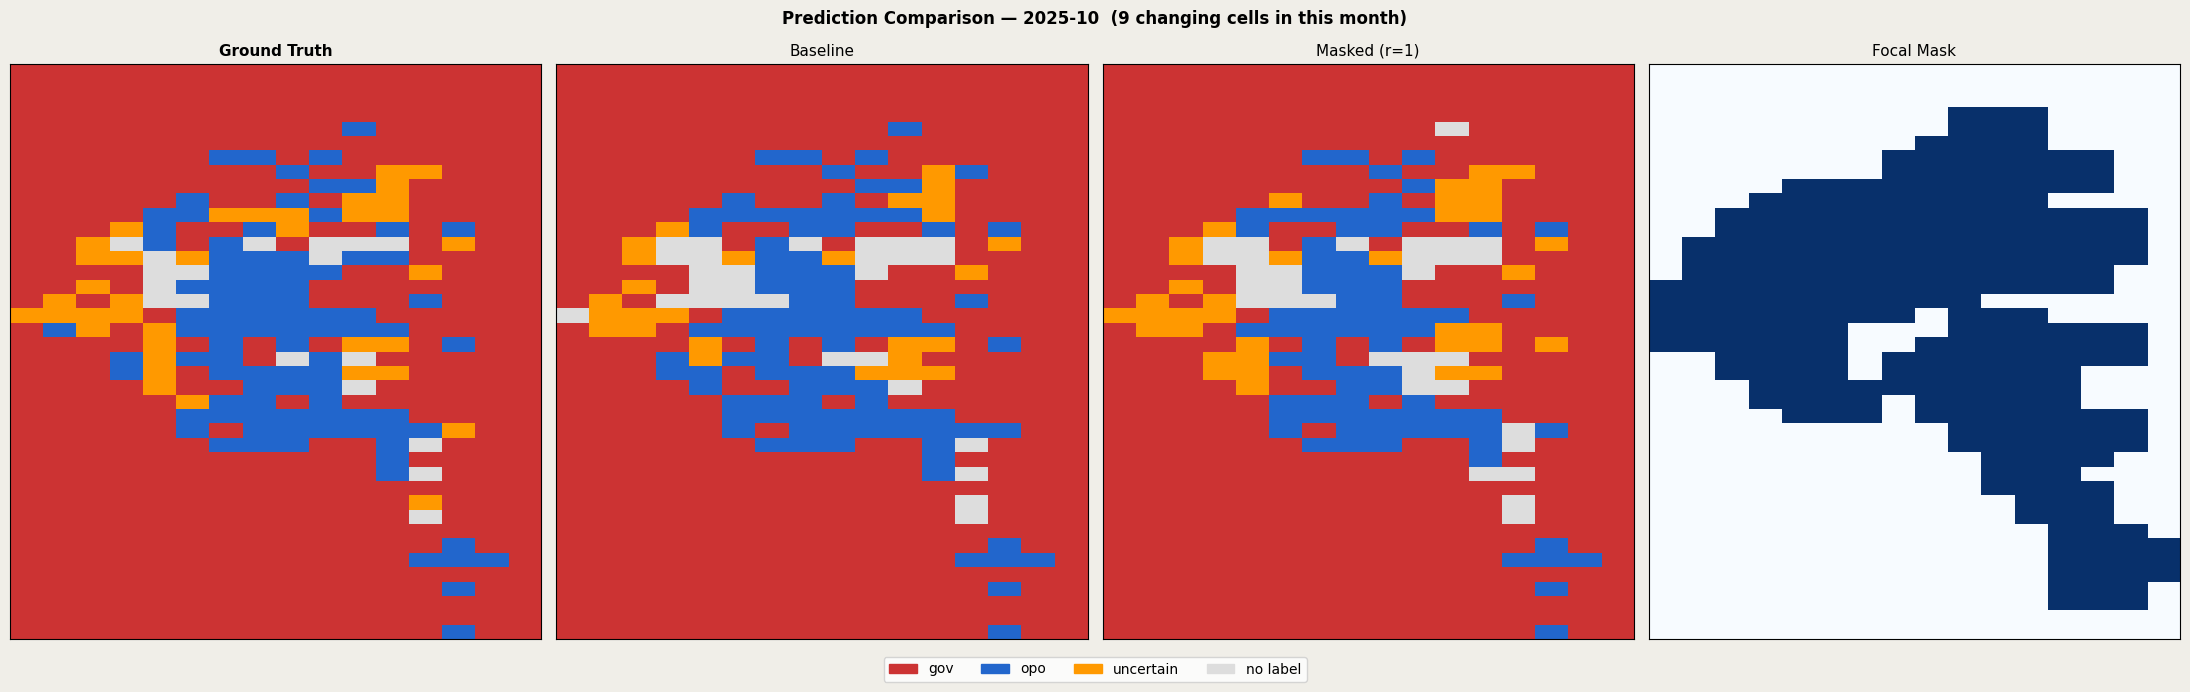

Prediction comparison figure saved.


In [11]:
# ── CELL 9: Visual Comparison ────────────────────────────────────────────────

# ── 9.1 Training curves side-by-side ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#F8F6F0')
fig.suptitle('Training History — Baseline vs Masked', fontsize=13, fontweight='bold')

for row_i, (hist, label, col) in enumerate([
    (history_base,   'Baseline',                  '#CC3333'),
    (history_masked, f'Masked (r={NEIGHBOR_RADIUS})', '#2266CC'),
]):
    epochs = range(1, len(hist['train_loss']) + 1)

    ax = axes[row_i, 0]
    ax.set_facecolor('#F8F6F0')
    ax.plot(epochs, hist['train_loss'], color=col,      linewidth=2, label='Train')
    ax.plot(epochs, hist['val_loss'],   color=col, lw=2, linestyle='--', label='Val')
    ax.axvline(FREEZE_EPOCHS, color='grey', linestyle=':', alpha=0.6)
    ax.set_title(f'{label} — Loss', fontsize=10); ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[row_i, 1]
    ax.set_facecolor('#F8F6F0')
    ax.plot(epochs, hist['val_acc'],           color=col,      lw=2, label='Overall')
    ax.plot(epochs, hist['val_acc_gov'],        color='#CC3333', lw=1.5, linestyle='--', label='gov')
    ax.plot(epochs, hist['val_acc_opo'],        color='#2266CC', lw=1.5, linestyle='--', label='opo')
    ax.plot(epochs, hist['val_acc_uncertain'],  color='#FF9900', lw=1.5, linestyle='--', label='unc')
    ax.axvline(FREEZE_EPOCHS, color='grey', linestyle=':', alpha=0.6)
    ax.set_title(f'{label} — Val Accuracy', fontsize=10); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[row_i, 2]
    ax.set_facecolor('#F8F6F0')
    ax.plot(epochs, hist['lr'], color=col, lw=2)
    ax.axvline(FREEZE_EPOCHS, color='grey', linestyle=':', alpha=0.6)
    ax.set_title(f'{label} — Learning Rate', fontsize=10); ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(REPORTS / 'focal_mask_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved.')


# ── 9.2 Side-by-side prediction maps for one held-out month ──────────────────
# Pick the first validation month with the most actual change events.

# Find validation month with most changing cells (interesting to visualise)
def count_changes_in_month(month):
    rows = labelled[labelled['year_month'] == month]
    n = 0
    for _, row in rows.iterrows():
        gid = int(row['priogrid_gid'])
        prev = label_lookup.get((gid, prev_ym(month)))
        if prev is not None and prev != int(row['label_int']):
            n += 1
    return n

change_counts = {m: count_changes_in_month(m) for m in val_month_keys}
showcase_month = max(change_counts, key=change_counts.get)
sc_idx = val_month_keys.index(showcase_month)
print(f'Showcase month: {showcase_month}  ({change_counts[showcase_month]} changing cells)')

label_cmap   = mcolors.ListedColormap(['#CC3333','#2266CC','#FF9900','#DDDDDD'])
label_bounds = [-1.5,-0.5,0.5,1.5,2.5]
label_norm   = mcolors.BoundaryNorm(label_bounds, label_cmap.N)

# Build prediction rasters for this month
def month_pred_raster(model, month_idx):
    model.eval()
    with torch.no_grad():
        X_t    = torch.from_numpy(X_val[month_idx]).unsqueeze(0).to(DEVICE)
        logits = model(X_t)
        preds  = torch.argmax(logits, dim=1)[0].cpu().numpy()  # (H, W)
    masked = preds.astype(float)
    masked[m_val[month_idx] == 0] = -1   # grey for unlabelled
    return masked

pred_base_r   = month_pred_raster(model_base,   sc_idx)
pred_masked_r = month_pred_raster(model_masked, sc_idx)
true_r        = y_val[sc_idx].astype(float)

fig, axes = plt.subplots(1, 4, figsize=(22, 7), facecolor='#F0EEE8')
fig.suptitle(
    f'Prediction Comparison — {showcase_month}'
    f'  ({change_counts[showcase_month]} changing cells in this month)',
    fontsize=12, fontweight='bold'
)

titles = ['Ground Truth', 'Baseline', f'Masked (r={NEIGHBOR_RADIUS})', 'Focal Mask']
rasters = [true_r, pred_base_r, pred_masked_r, None]

for i, (ax, title, raster) in enumerate(zip(axes, titles, rasters)):
    if raster is not None:
        ax.imshow(raster, cmap=label_cmap, norm=label_norm, origin='lower', aspect='auto')
    else:
        # Show the focal mask
        ax.imshow(focal_mask_np.astype(float), cmap='Blues', origin='lower',
                  aspect='auto', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold' if i == 0 else 'normal')
    ax.set_xticks([]); ax.set_yticks([])

patches = [
    mpatches.Patch(color='#CC3333', label='gov'),
    mpatches.Patch(color='#2266CC', label='opo'),
    mpatches.Patch(color='#FF9900', label='uncertain'),
    mpatches.Patch(color='#DDDDDD', label='no label'),
]
fig.legend(handles=patches, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(REPORTS / f'focal_mask_pred_comparison_{showcase_month}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Prediction comparison figure saved.')
